<a href="https://colab.research.google.com/github/Anastasia-Pom/Machine-learning-2026/blob/main/%D0%9B%D0%A02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
sns.set(style="ticks")
from sklearn.impute import SimpleImputer
from sklearn.impute import MissingIndicator

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
drive_file_path = "/content/drive/MyDrive/synthetic_coffee_health_10000.csv"
data = pd.read_csv("/content/drive/MyDrive/synthetic_coffee_health_10000.csv")

data.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,ID,Age,Gender,Country,Coffee_Intake,Caffeine_mg,Sleep_Hours,Sleep_Quality,BMI,Heart_Rate,Stress_Level,Physical_Activity_Hours,Health_Issues,Occupation,Smoking,Alcohol_Consumption
0,1,40,Male,Germany,3.5,328.1,7.5,Good,24.9,78,Low,14.5,No,Other,0,0
1,2,33,Male,Germany,1.0,94.1,6.2,Good,20.0,67,Low,11.0,No,Service,0,0
2,3,42,Male,Brazil,5.3,503.7,5.9,Fair,22.7,59,Medium,11.2,Mild,Office,0,0
3,4,53,Male,Germany,2.6,249.2,7.3,Good,24.7,71,Low,6.6,Mild,Other,0,0
4,5,32,Female,Spain,3.1,298.0,5.3,Fair,24.1,76,Medium,8.5,Mild,Student,0,1


In [ ]:
data.shape
data.dtypes

,0
ID,int64
Age,int64
Gender,object
Country,object
Coffee_Intake,float64
Caffeine_mg,float64
Sleep_Hours,float64
Sleep_Quality,object
BMI,float64
Heart_Rate,int64


In [ ]:
data.isnull().sum()

,0
ID,0
Age,0
Gender,0
Country,0
Coffee_Intake,0
Caffeine_mg,0
Sleep_Hours,0
Sleep_Quality,0
BMI,0
Heart_Rate,0


In [ ]:
total_count = data.shape[0]
print('Всего строк: {}'.format(total_count))

Всего строк: 10000


In [ ]:
cat_cols = []
for col in data.columns:
    temp_null_count = data[data[col].isnull()].shape[0]
    dt = str(data[col].dtype)
    if temp_null_count>0 and (dt=='object'):
        cat_cols.append(col)
        temp_perc = round((temp_null_count / total_count) * 100.0, 2)
        print('Колонка {}. Тип данных {}. Количество пустых значений {}, {}%.'.format(col, dt, temp_null_count, temp_perc))

Колонка Stress_Level. Тип данных object. Количество пустых значений 13, 0.13%.


In [ ]:
cat_temp_data = data[['Health_Issues']]
cat_temp_data.head()
cat_temp_data['Health_Issues'].unique()
cat_temp_data[cat_temp_data['Health_Issues'].isnull()].shape
imp3 = SimpleImputer(missing_values=np.nan, strategy='constant', fill_value='No')
data_imp3 = imp3.fit_transform(cat_temp_data)
data_imp3

array([['No'],
       ['No'],
       ['Mild'],
       ...,
       ['No'],
       ['No'],
       ['No']], dtype=object)

In [ ]:
data_imp3[data_imp3=='No'].size

5941

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer
from sklearn.impute import MissingIndicator
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Lasso
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from IPython.display import Image
%matplotlib inline
sns.set(style="ticks")

In [ ]:
def impute_column(dataset, column, strategy_param, fill_value_param=None):
    temp_data = dataset[[column]].values
    size = temp_data.shape[0]

    indicator = MissingIndicator()
    mask_missing_values_only = indicator.fit_transform(temp_data)

    imputer = SimpleImputer(strategy=strategy_param,
                            fill_value=fill_value_param)
    all_data = imputer.fit_transform(temp_data)

    missed_data = temp_data[mask_missing_values_only]
    filled_data = all_data[mask_missing_values_only]

    return all_data.reshape((size,)), filled_data, missed_data

In [ ]:
def plot_hist_diff(old_ds, new_ds, cols):
    for c in cols:
        fig = plt.figure()
        ax = fig.add_subplot(111)
        ax.title.set_text('Поле - ' + str(c))
        old_ds[c].hist(bins=50, ax=ax, density=True, color='green')
        new_ds[c].hist(bins=50, ax=ax, color='blue', density=True, alpha=0.5)
        plt.show()

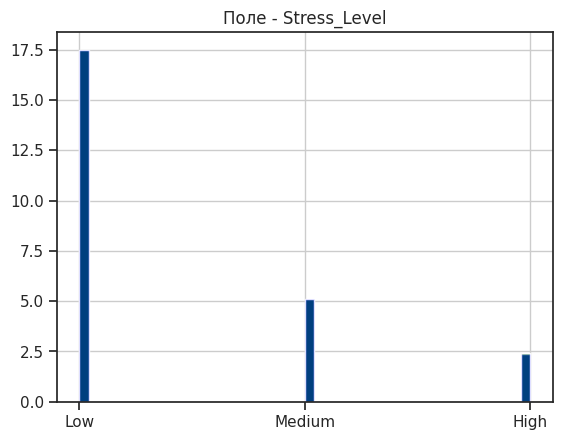

In [ ]:
data_cat_cols = ['Stress_Level']
data_cat_new = data[data_cat_cols].copy()
Stress_Level_cat_new_temp, _, _ = impute_column(data_cat_new, 'Stress_Level', 'most_frequent')
data_cat_new['Stress_Level'] = Stress_Level_cat_new_temp
plot_hist_diff(data, data_cat_new, data_cat_cols)

In [ ]:
stress = data_cat_new['Stress_Level']
pd_stress = pd.DataFrame(data={'Stress_Level':stress})
pd_stress['stress_codes'] = pd_stress['Stress_Level'].map({'Low':1, 'Medium':2, 'High':3})
pd_stress

,Stress_Level,stress_codes
0,Low,1
1,Low,1
2,Medium,2
3,Low,1
4,Medium,2
...,...,...
9995,Medium,2
9996,Medium,2
9997,Low,1
9998,Low,1


In [ ]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler, Normalizer

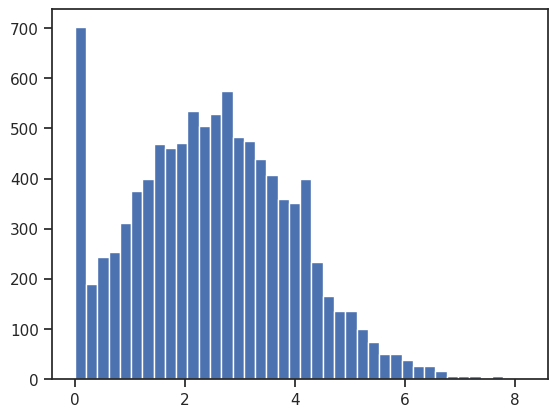

In [ ]:
sc1 = MinMaxScaler()
sc1_data = sc1.fit_transform(data[['Coffee_Intake']])
plt.hist(data['Coffee_Intake'], 40)
plt.show()

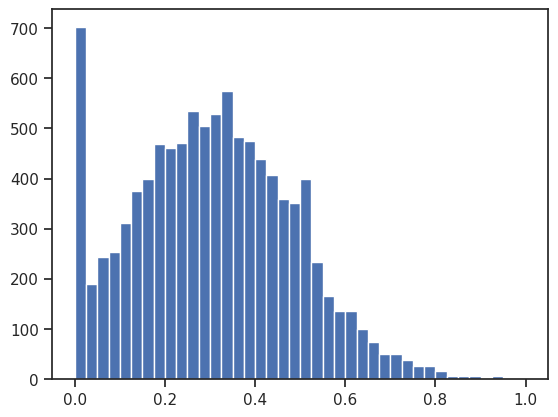

In [ ]:
plt.hist(sc1_data, 40)
plt.show()